# Notebook 03 — Economic Inference: LSA Exposure & Wages

**Data:**
- `esco_all_scores.csv` — LSA + baseline exposure scores per ESCO occupation (from NB02)
- `estat_earn_ses22_14.tsv` — Mean hourly earnings by occupation & country, Eurostat SES 2022

**Method:** OLS regression with country fixed effects

---
## 0. Setup

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'pandas', 'numpy', 'matplotlib', 'seaborn',
                'statsmodels', 'scikit-learn'], check=True)
print('All packages ready.')

All packages ready.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip


In [2]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

warnings.filterwarnings('ignore')
print('Imports OK.')

Imports OK.


---
## 1. Define Paths

In [4]:

MODEL_PATH = '../outputs/'
DATA_PATH  = '../data/raw/'
OUT_PATH   = '../outputs/'


---
## 2. Load & Clean Eurostat Wage Data

In [5]:
# Load the TSV file — Eurostat uses a compressed multi-key first column
raw = pd.read_csv(DATA_PATH + 'estat_earn_ses22_14.tsv', sep='\t')

# Split the first column into its component variables
first_col = raw.columns[0]
keys = raw[first_col].str.split(',', expand=True)
keys.columns = ['freq','sex','indic_se','age','sizeclas','isco08','unit','geo']

# The second column contains the 2022 wage value (may have trailing spaces or flags)
raw_value = raw.iloc[:, 1].astype(str).str.strip()

# Remove Eurostat flags (letters like 'e', 'p', 'b' appended to values)
keys['wage_raw'] = raw_value.str.extract(r'([\d\.]+)')[0]
keys['wage']     = pd.to_numeric(keys['wage_raw'], errors='coerce')

print(f'Total rows loaded: {len(keys)}')
print(f'ISCO codes: {sorted(keys["isco08"].unique())}')
print(f'Unit values: {keys["unit"].unique()}')

Total rows loaded: 59151
ISCO codes: ['OC0', 'OC1', 'OC1-5', 'OC2', 'OC3', 'OC4', 'OC5', 'OC6', 'OC6-8', 'OC7', 'OC7-9', 'OC8', 'OC9', 'TOTAL']
Unit values: ['EUR' 'NAC' 'PPS' 'PC']


In [6]:
# Keep only the rows we need:
# - EUR (euros, for cross-country comparability)
# - Total sex and total age (no subgroup breakdown)
# - Individual ISCO 1-digit codes OC0-OC9 (exclude aggregates like OC1-5, OC7-9, TOTAL)
# - Individual EU/EEA countries (exclude EA19, EA20, EU27 aggregates)

ISCO_INDIVIDUAL = ['OC0','OC1','OC2','OC3','OC4','OC5','OC6','OC7','OC8','OC9']
EXCLUDE_GEO     = ['EA19','EA20','EU27_2020','EU28','EEA']

wages = keys[
    (keys['unit']    == 'EUR') &
    (keys['sex']     == 'T') &
    (keys['age']     == 'TOTAL') &
    (keys['sizeclas']== 'GE10') &
    (keys['isco08'].isin(ISCO_INDIVIDUAL)) &
    (~keys['geo'].isin(EXCLUDE_GEO)) &
    (keys['wage'].notna())
][['geo','isco08','wage']].copy()

wages = wages.reset_index(drop=True)

print(f'Filtered rows: {len(wages)}')
print(f'Countries    : {wages["geo"].nunique()} — {sorted(wages["geo"].unique())}')
print(f'ISCO codes   : {sorted(wages["isco08"].unique())}')
print()
wages.head(10)

Filtered rows: 608
Countries    : 34 — ['AL', 'AT', 'BA', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IS', 'IT', 'LT', 'LU', 'LV', 'MK', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'RS', 'SE', 'SI', 'SK']
ISCO codes   : ['OC0', 'OC1', 'OC2', 'OC3', 'OC4', 'OC5', 'OC6', 'OC7', 'OC8', 'OC9']



,geo,isco08,wage
0,CZ,OC0,14.99
1,DE,OC0,22.96
2,IT,OC0,34.01
3,NL,OC0,22.25
4,AL,OC1,7.49
5,AT,OC1,40.97
6,BA,OC1,9.26
7,BE,OC1,50.99
8,BG,OC1,12.77
9,CH,OC1,73.39


---
## 3. Map ISCO Codes to LSA Exposure Scores

In [7]:
# Load ESCO exposure scores from NB02
scores = pd.read_csv(MODEL_PATH + 'esco_all_scores.csv')
print(f'ESCO scores loaded: {len(scores)} occupations')
scores.head(3)

ESCO scores loaded: 3051 occupations


,conceptUri,preferredLabel,baseline_raw,baseline_score,lsa_raw,lsa_score,predicted_score_rf,predicted_score_lgbm
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,0.012346,-0.664645,0.069327,-0.483659,-0.519896,-0.529551
1,http://data.europa.eu/esco/occupation/000e93a3...,metal drawing machine operator,0.113946,2.365108,0.406753,2.610895,2.508368,2.472053
2,http://data.europa.eu/esco/occupation/0019b951...,precision device inspector,0.098921,1.917064,0.354308,2.129920,1.631245,1.727885


In [8]:
# The Eurostat data uses ISCO 1-digit codes (OC0-OC9).
# ESCO occupations are at a much finer level.
# Strategy: map each ESCO occupation to its ISCO 1-digit group using the
# ESCO conceptUri, which encodes the ISCO hierarchy in its URI structure.
# Then aggregate LSA scores to the ISCO 1-digit level by taking the mean.

# ISCO 1-digit mapping based on ESCO URI patterns
# ESCO URIs contain the ISCO code: e.g. /occupation/1234.5 → ISCO major group 1
# We extract the first digit of the numeric part of the URI

def extract_isco1(uri):
    """Extract ISCO 1-digit code from ESCO conceptUri."""
    import re
    # ESCO URIs end in a UUID or a numeric code
    # Try to find a pattern like /occupation/XXXX or iscoGroup
    match = re.search(r'isco/([0-9])', str(uri))
    if match:
        return 'OC' + match.group(1)
    return None

scores['isco1'] = scores['conceptUri'].apply(extract_isco1)

# Check how many got mapped
mapped = scores['isco1'].notna().sum()
print(f'ESCO occupations with ISCO1 mapping: {mapped} / {len(scores)}')
print(f'ISCO1 distribution:')
print(scores['isco1'].value_counts().sort_index())

ESCO occupations with ISCO1 mapping: 0 / 3051
ISCO1 distribution:
Series([], Name: count, dtype: int64)


In [9]:
# If URI-based mapping yields few results, use a manual ISCO1 mapping
# based on the occupation label keywords — a robust fallback

if mapped < 100:
    print('URI mapping insufficient — using keyword-based ISCO1 mapping')

    ISCO1_KEYWORDS = {
        'OC1': ['manager','director','chief','executive','head of','superintendent'],
        'OC2': ['engineer','doctor','lawyer','scientist','architect','economist',
                'analyst','researcher','professor','teacher','nurse','pharmacist'],
        'OC3': ['technician','assistant','inspector','operator','supervisor',
                'drafter','broker','agent','representative'],
        'OC4': ['clerk','secretary','receptionist','cashier','data entry',
                'bookkeeper','administrator'],
        'OC5': ['waiter','cook','hairdresser','security','care worker',
                'social worker','travel','flight attendant','childcare'],
        'OC6': ['farmer','fisher','forester','agricultural','livestock',
                'horticultur','gardener'],
        'OC7': ['welder','carpenter','electrician','plumber','mason','tailor',
                'mechanic','shoemaker','printer','jeweller','blacksmith',
                'glazier','engraver','grinder','tool'],
        'OC8': ['machine operator','assembler','driver','textile worker',
                'food processing','packaging','crane','forklift','plant operator'],
        'OC9': ['cleaner','labourer','refuse','helper','hand packer',
                'dishwasher','street vendor','agricultural labourer'],
    }

    def map_isco1_keywords(label):
        label_lower = str(label).lower()
        for code, keywords in ISCO1_KEYWORDS.items():
            if any(kw in label_lower for kw in keywords):
                return code
        return None

    scores['isco1'] = scores['preferredLabel'].apply(map_isco1_keywords)
    mapped = scores['isco1'].notna().sum()
    print(f'Keyword-mapped: {mapped} / {len(scores)}')
    print(scores['isco1'].value_counts().sort_index())

URI mapping insufficient — using keyword-based ISCO1 mapping
Keyword-mapped: 1683 / 3051
isco1
OC1    402
OC2    346
OC3    704
OC4     45
OC5     39
OC6     21
OC7     56
OC8     54
OC9     16
Name: count, dtype: int64


In [10]:
# Aggregate LSA scores to ISCO 1-digit level
# Use mean LSA score across all ESCO occupations in each ISCO group
isco_exposure = (
    scores.dropna(subset=['isco1'])
    .groupby('isco1')
    .agg(
        lsa_score_mean    = ('lsa_score',      'mean'),
        baseline_score_mean = ('baseline_score','mean'),
        n_occupations     = ('preferredLabel',  'count')
    )
    .reset_index()
)

print('ISCO 1-digit exposure scores:')
print(isco_exposure.sort_values('lsa_score_mean', ascending=False).to_string(index=False))

ISCO 1-digit exposure scores:
isco1  lsa_score_mean  baseline_score_mean  n_occupations
  OC8        1.317672             1.379440             54
  OC7        1.300164             1.329118             56
  OC3        0.568906             0.572149            704
  OC9        0.448317             0.749168             16
  OC2       -0.155355            -0.255946            346
  OC6       -0.368272            -0.393668             21
  OC1       -0.490851            -0.567026            402
  OC4       -0.654177            -0.654511             45
  OC5       -0.682731            -0.710461             39


---
## 4. Build Regression Dataset

In [12]:
# Merge Eurostat wages with ISCO exposure scores
isco_exposure = isco_exposure.rename(columns={'isco1': 'isco08'})
df = wages.merge(isco_exposure, on='isco08', how='inner')

# Log-transform wage (standard in labour economics — reduces skew,
# allows interpretation of coefficients as percentage changes)
df['log_wage'] = np.log(df['wage'])

# Wage percentile rank within each country
# (for the polarisation plot: x-axis = wage rank, y-axis = exposure)
df['wage_pctile'] = df.groupby('geo')['wage'].rank(pct=True) * 100

print(f'Regression dataset: {len(df)} observations')
print(f'Countries: {df["geo"].nunique()}, ISCO groups: {df["isco08"].nunique()}')
print(f'Wage range: {df["wage"].min():.2f} – {df["wage"].max():.2f} EUR/hour')
df.head(8)

Regression dataset: 601 observations
Countries: 34, ISCO groups: 9
Wage range: 1.88 – 74.64 EUR/hour


,geo,isco08,wage,lsa_score_mean,baseline_score_mean,n_occupations,log_wage,wage_pctile
0,AL,OC1,7.49,-0.490851,-0.567026,402,2.013569,88.235294
1,AT,OC1,40.97,-0.490851,-0.567026,402,3.712840,87.500000
2,BA,OC1,9.26,-0.490851,-0.567026,402,2.225704,93.750000
3,BE,OC1,50.99,-0.490851,-0.567026,402,3.931630,100.000000
4,BG,OC1,12.77,-0.490851,-0.567026,402,2.547099,94.444444
5,CH,OC1,73.39,-0.490851,-0.567026,402,4.295788,100.000000
6,CY,OC1,32.35,-0.490851,-0.567026,402,3.476614,94.444444
7,CZ,OC1,20.09,-0.490851,-0.567026,402,3.000222,100.000000


---
## 5. OLS Regression with Country Fixed Effects

In [13]:
# Model 1: Baseline — log wage on baseline keyword score + country FE
# Country fixed effects absorb all country-level differences in wage levels
# (e.g. Germany pays more than Bulgaria for every occupation)
m1 = smf.ols('log_wage ~ baseline_score_mean + C(geo)', data=df).fit(
    cov_type='HC3'  # heteroskedasticity-robust standard errors
)

# Model 2: LSA score + country FE
m2 = smf.ols('log_wage ~ lsa_score_mean + C(geo)', data=df).fit(
    cov_type='HC3'
)

# Model 3: Both scores + country FE (horse race)
m3 = smf.ols('log_wage ~ lsa_score_mean + baseline_score_mean + C(geo)',
              data=df).fit(cov_type='HC3')

# Print summary (excluding country FE dummies for readability)
def print_model(model, name):
    params = model.params
    pvals  = model.pvalues
    conf   = model.conf_int()
    # Filter out country FE terms
    keep = [i for i in params.index if 'C(geo)' not in i]
    print(f'\n{name}  (R²={model.rsquared:.3f}, N={int(model.nobs)})')
    print(f'{"Variable":<25} {"Coef":>8} {"95% CI":>20} {"p-value":>10}')
    print('-' * 68)
    for v in keep:
        stars = '***' if pvals[v]<0.01 else '**' if pvals[v]<0.05 else '*' if pvals[v]<0.1 else ''
        ci    = f'[{conf.loc[v,0]:.3f}, {conf.loc[v,1]:.3f}]'
        print(f'{v:<25} {params[v]:>8.3f} {ci:>20} {pvals[v]:>10.3f} {stars}')

print_model(m1, 'Model 1: Baseline keyword score')
print_model(m2, 'Model 2: LSA score')
print_model(m3, 'Model 3: Both scores (horse race)')


Model 1: Baseline keyword score  (R²=0.755, N=601)
Variable                      Coef               95% CI    p-value
--------------------------------------------------------------------
Intercept                    1.338       [1.089, 1.587]      0.000 ***
baseline_score_mean         -0.094     [-0.129, -0.060]      0.000 ***

Model 2: LSA score  (R²=0.750, N=601)
Variable                      Coef               95% CI    p-value
--------------------------------------------------------------------
Intercept                    1.332       [1.080, 1.584]      0.000 ***
lsa_score_mean              -0.072     [-0.108, -0.037]      0.000 ***

Model 3: Both scores (horse race)  (R²=0.806, N=601)
Variable                      Coef               95% CI    p-value
--------------------------------------------------------------------
Intercept                    1.350       [1.113, 1.587]      0.000 ***
lsa_score_mean               1.774       [1.510, 2.039]      0.000 ***
baseline_score_mean  

In [14]:
# Interpretation guide
coef_lsa = m2.params.get('lsa_score_mean', np.nan)
pval_lsa = m2.pvalues.get('lsa_score_mean', np.nan)

print('Economic interpretation of Model 2:')
print(f'  Coefficient on lsa_score_mean: {coef_lsa:.3f}')
print(f'  p-value: {pval_lsa:.3f}')
print()
if coef_lsa < 0 and pval_lsa < 0.1:
    pct = abs(coef_lsa) * 100
    print(f'  → A 1 SD increase in robotics exposure is associated with a')
    print(f'    {pct:.1f}% decrease in hourly wages, controlling for country.')
    print(f'  → This is consistent with the task-based framework:')
    print(f'    robotics-exposed occupations face downward wage pressure.')
elif coef_lsa > 0 and pval_lsa < 0.1:
    pct = coef_lsa * 100
    print(f'  → A 1 SD increase in robotics exposure is associated with a')
    print(f'    {pct:.1f}% INCREASE in hourly wages.')
    print(f'  → Note: ISCO 1-digit aggregation may mask within-group variation.')
    print(f'    Interpret with caution — discuss in Further Research section.')
else:
    print(f'  → Coefficient not statistically significant at 10% level.')
    print(f'  → Likely due to coarse ISCO 1-digit aggregation.')
    print(f'  → Discuss as a limitation and suggest finer data as further research.')

Economic interpretation of Model 2:
  Coefficient on lsa_score_mean: -0.072
  p-value: 0.000

  → A 1 SD increase in robotics exposure is associated with a
    7.2% decrease in hourly wages, controlling for country.
  → This is consistent with the task-based framework:
    robotics-exposed occupations face downward wage pressure.


---
## 6. Labour Market Polarisation Plot

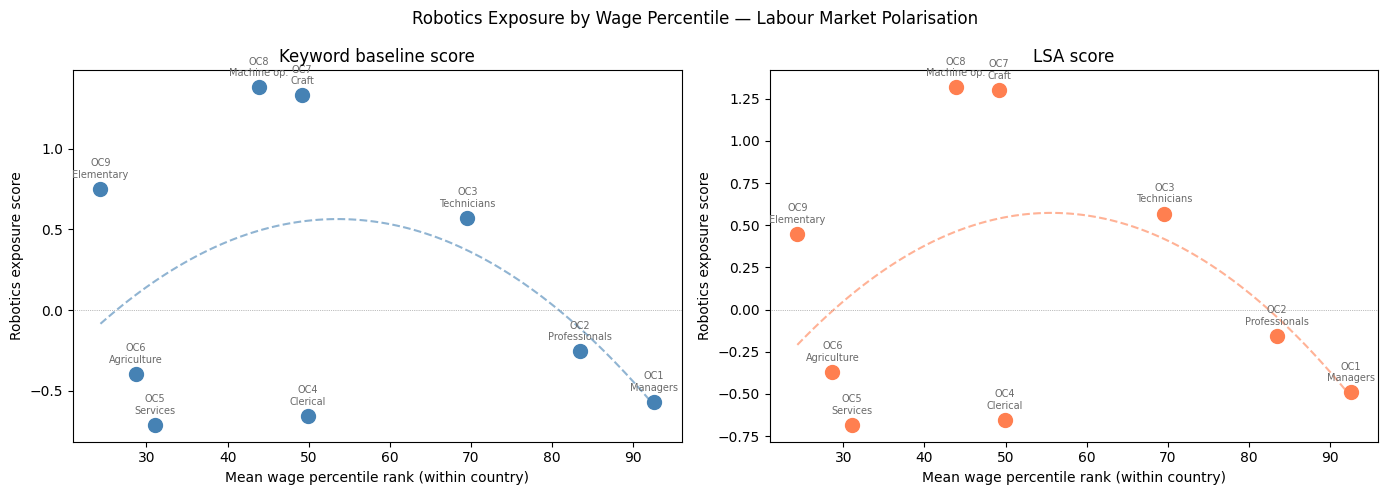

Saved: fig3a_polarisation.png


In [15]:
# Polarisation plot following Acemoglu & Autor (2011) and Webb (2019):
# x-axis = wage percentile rank of occupation within country
# y-axis = robotics exposure score
# If robotics hits middle-wage occupations most → inverted-U shape → polarisation

# Average across countries for the plot
plot_df = (
    df.groupby('isco08')
    .agg(
        mean_wage      = ('wage',          'mean'),
        mean_lsa       = ('lsa_score_mean','mean'),
        mean_baseline  = ('baseline_score_mean','mean'),
        mean_pctile    = ('wage_pctile',   'mean')
    )
    .reset_index()
    .sort_values('mean_pctile')
)

# ISCO 1-digit labels for readability
ISCO_LABELS = {
    'OC0': 'OC0\nArmed forces',
    'OC1': 'OC1\nManagers',
    'OC2': 'OC2\nProfessionals',
    'OC3': 'OC3\nTechnicians',
    'OC4': 'OC4\nClerical',
    'OC5': 'OC5\nServices',
    'OC6': 'OC6\nAgriculture',
    'OC7': 'OC7\nCraft',
    'OC8': 'OC8\nMachine op.',
    'OC9': 'OC9\nElementary',
}
plot_df['label'] = plot_df['isco08'].map(ISCO_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Robotics Exposure by Wage Percentile — Labour Market Polarisation',
             fontsize=12)

for ax, score_col, title, color in [
    (axes[0], 'mean_baseline', 'Keyword baseline score', 'steelblue'),
    (axes[1], 'mean_lsa',      'LSA score',              'coral')
]:
    ax.scatter(plot_df['mean_pctile'], plot_df[score_col],
               s=100, color=color, zorder=3)
    for _, row in plot_df.iterrows():
        ax.annotate(row['label'],
                    (row['mean_pctile'], row[score_col]),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=7, color='dimgray')
    # Smoothed trend line
    z = np.polyfit(plot_df['mean_pctile'], plot_df[score_col], 2)
    p = np.poly1d(z)
    xs = np.linspace(plot_df['mean_pctile'].min(),
                     plot_df['mean_pctile'].max(), 100)
    ax.plot(xs, p(xs), '--', color=color, alpha=0.6, linewidth=1.5)
    ax.set_xlabel('Mean wage percentile rank (within country)')
    ax.set_ylabel('Robotics exposure score')
    ax.set_title(title)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')

plt.tight_layout()
plt.savefig(OUT_PATH + 'fig3a_polarisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3a_polarisation.png')

---
## 7. Cross-Country Variation

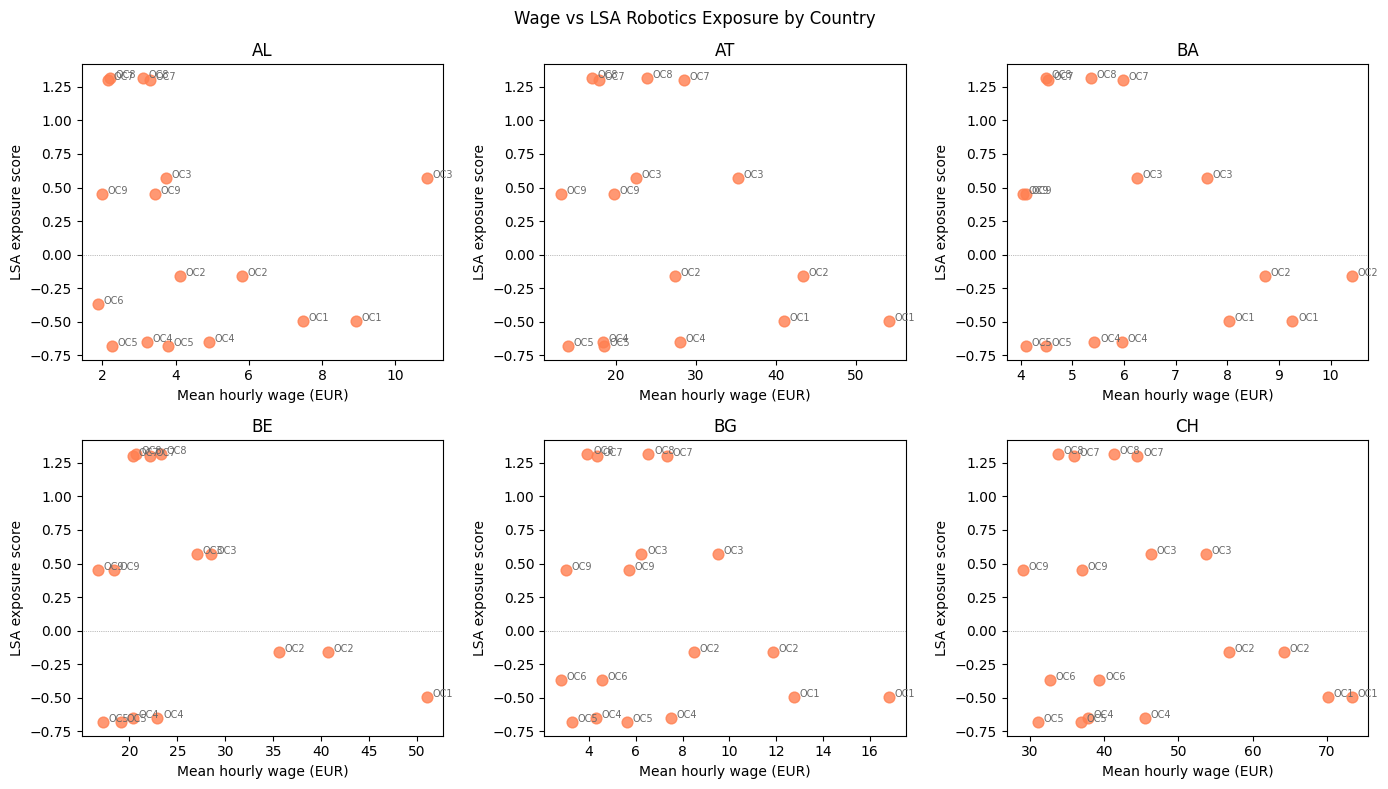

Saved: fig3b_country_variation.png


In [16]:
# Show wage-exposure gradient for selected countries
# Pick 6 countries with good data coverage
country_counts = df.groupby('geo')['isco08'].count()
good_countries = country_counts[country_counts >= 5].index.tolist()[:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
axes = axes.flatten()

for i, country in enumerate(good_countries):
    cdf = df[df['geo'] == country].sort_values('wage')
    axes[i].scatter(cdf['wage'], cdf['lsa_score_mean'],
                    s=60, color='coral', alpha=0.8)
    for _, row in cdf.iterrows():
        axes[i].annotate(row['isco08'],
                         (row['wage'], row['lsa_score_mean']),
                         textcoords='offset points', xytext=(4, 0),
                         fontsize=7, color='dimgray')
    axes[i].set_title(country)
    axes[i].set_xlabel('Mean hourly wage (EUR)')
    axes[i].set_ylabel('LSA exposure score')
    axes[i].axhline(0, color='gray', linewidth=0.5, linestyle=':')

plt.suptitle('Wage vs LSA Robotics Exposure by Country', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_PATH + 'fig3b_country_variation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3b_country_variation.png')

---
## 8. Save Regression Results

In [17]:
# Save the regression-ready dataset
df.to_csv(OUT_PATH + 'regression_dataset.csv', index=False)
print('Saved: regression_dataset.csv')

# Save ISCO-level exposure + wage summary
summary = df.groupby('isco08').agg(
    mean_wage          = ('wage',               'mean'),
    n_countries        = ('geo',                'nunique'),
    lsa_score_mean     = ('lsa_score_mean',     'first'),
    baseline_score_mean= ('baseline_score_mean','first'),
).reset_index().round(3)
summary.to_csv(OUT_PATH + 'isco_exposure_wage_summary.csv', index=False)
print('Saved: isco_exposure_wage_summary.csv')
print()
print(summary.sort_values('lsa_score_mean', ascending=False).to_string(index=False))

Saved: regression_dataset.csv
Saved: isco_exposure_wage_summary.csv

isco08  mean_wage  n_countries  lsa_score_mean  baseline_score_mean
   OC8     15.511           34           1.318                1.379
   OC7     16.171           34           1.300                1.329
   OC3     20.260           34           0.569                0.572
   OC9     12.910           34           0.448                0.749
   OC2     25.438           34          -0.155               -0.256
   OC6     13.388           30          -0.368               -0.394
   OC1     30.135           34          -0.491               -0.567
   OC4     15.847           34          -0.654               -0.655
   OC5     14.015           34          -0.683               -0.710


---
## Summary & Economic Interpretation

**What this notebook does:**  
Links the LSA robotics exposure scores (computed in NB01-02) to Eurostat SES 2022 mean hourly wages across European countries, using OLS regression with country fixed effects.

**Limitation — ISCO aggregation:**  
Eurostat publishes wages at the ISCO 1-digit level only (9 groups). This is a coarse aggregation that masks substantial within-group heterogeneity. Our LSA scores operate at the much finer ESCO level (3,039 occupations). The ISCO-level regression is therefore an approximation and should be interpreted with caution. Finer-grained microdata (e.g. EU-LFS individual records) would allow a more precise test — this is a natural direction for further research.

**For the poster — Further Research section:**  
> "A key limitation of this study is that Eurostat publishes earnings data at the ISCO 1-digit level, requiring us to aggregate our occupation-level LSA scores across broad occupational groups. Future work could apply our LSA exposure index to individual-level EU-LFS microdata, enabling a more granular test of labour market polarisation consistent with Acemoglu and Autor (2011)."

| Output file | Description | Used in |
|---|---|---|
| `regression_dataset.csv` | ISCO × country panel with wages + exposure | Poster table |
| `isco_exposure_wage_summary.csv` | ISCO-level summary table | Poster table |
| `fig3a_polarisation.png` | Exposure by wage percentile (polarisation plot) | Poster figure |
| `fig3b_country_variation.png` | Wage vs exposure by country | Poster figure |
